# Walmart Store Sales — Prophet v4 raw-pipeline inference

This notebook performs inference only:

```text
W&B Model Registry
→ ProphetRawPipeline
→ pipeline.predict(raw test.csv)
→ Kaggle submission + W&B submission artifact
```

The champion pipeline already contains 3,283 full-history fitted Prophet models, event-aware holiday settings, the 0.50 blend weight, sales history, and seasonal fallback logic. No Prophet model is refit here.


In [1]:
%pip install -q "prophet>=1.1,<2" "wandb>=0.19,<1" "pandas>=2.2,<3" "numpy>=1.26,<3" "matplotlib>=3.8,<4" "kaggle>=1.7,<2" "cloudpickle>=3,<4"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.5/75.5 kB 2.0 MB/s eta 0:00:00


In [2]:
from __future__ import annotations
import hashlib, json, subprocess
from pathlib import Path
import cloudpickle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import wandb
from prophet.serialize import model_from_json


In [3]:
try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception as exc:
    print(f"Not running in Colab or Drive unavailable: {exc}")


Mounted at /content/drive


## Configuration


In [4]:
CONFIG={
 "data_dir":"/content/drive/MyDrive/walmart_competition_data",
 "output_dir":"/content/drive/MyDrive/walmart_competition_inference/prophet",
 "download_dir":"/content/artifacts/prophet_raw_pipeline",
 "wandb_entity":"kende23-n-a","wandb_project":"Walmart-Recruiting---Store-Sales-Forecasting",
 "raw_pipeline_registry_uri":"wandb-registry-model/Walmart_Prophet_Raw_Pipeline:champion",
 "raw_pipeline_filename":"walmart_prophet_v4_raw_pipeline.pkl",
 "submission_artifact_name":"prophet-v4-registry-raw-pipeline-submission",
 "submit_to_kaggle":False,"kaggle_competition":"walmart-recruiting-store-sales-forecasting",
 "kaggle_message":"Prophet v4 event-aware 50/50 blend from W&B registry pipeline"}
DATA_DIR=Path(CONFIG["data_dir"]); OUTPUT_DIR=Path(CONFIG["output_dir"]); DOWNLOAD_DIR=Path(CONFIG["download_dir"])
OUTPUT_DIR.mkdir(parents=True,exist_ok=True); DOWNLOAD_DIR.mkdir(parents=True,exist_ok=True)
CONFIG


{'data_dir': '/content/drive/MyDrive/walmart_competition_data',
 'output_dir': '/content/drive/MyDrive/walmart_competition_inference/prophet',
 'download_dir': '/content/artifacts/prophet_raw_pipeline',
 'wandb_entity': 'kende23-n-a',
 'wandb_project': 'Walmart-Recruiting---Store-Sales-Forecasting',
 'raw_pipeline_registry_uri': 'wandb-registry-model/Walmart_Prophet_Raw_Pipeline:champion',
 'raw_pipeline_filename': 'walmart_prophet_v4_raw_pipeline.pkl',
 'submission_artifact_name': 'prophet-v4-registry-raw-pipeline-submission',
 'submit_to_kaggle': False,
 'kaggle_competition': 'walmart-recruiting-store-sales-forecasting',
 'kaggle_message': 'Prophet v4 event-aware 50/50 blend from W&B registry pipeline'}

## Load raw test data


In [5]:
test_raw=pd.read_csv(DATA_DIR/"test.csv",parse_dates=["Date"])
required={"Store","Dept","Date","IsHoliday"}; missing=sorted(required.difference(test_raw.columns))
if missing: raise ValueError({"missing_raw_test_columns":missing})
test_raw=test_raw.sort_values(["Store","Dept","Date"]).reset_index(drop=True)
print({"rows":len(test_raw),"columns":test_raw.columns.tolist(),"date_range":(str(test_raw.Date.min().date()),str(test_raw.Date.max().date()))})
display(test_raw.head())


{'rows': 115064, 'columns': ['Store', 'Dept', 'Date', 'IsHoliday'], 'date_range': ('2012-11-02', '2013-07-26')}


,Store,Dept,Date,IsHoliday
0,1,1,2012-11-02,False
1,1,1,2012-11-09,False
2,1,1,2012-11-16,False
3,1,1,2012-11-23,True
4,1,1,2012-11-30,False


## Download champion pipeline from W&B Registry


In [6]:
run=wandb.init(entity=CONFIG["wandb_entity"],project=CONFIG["wandb_project"],group="prophet-inference",job_type="prophet_raw_pipeline_inference",name="prophet_v4_registry_raw_pipeline_inference",config=CONFIG)
pipeline_artifact=run.use_artifact(CONFIG["raw_pipeline_registry_uri"])
pipeline_dir=Path(pipeline_artifact.download(root=str(DOWNLOAD_DIR)))
pipeline_path=pipeline_dir/CONFIG["raw_pipeline_filename"]
if not pipeline_path.exists():
    candidates=sorted(pipeline_dir.glob("*.pkl"))
    if len(candidates)!=1: raise FileNotFoundError({"expected":str(pipeline_path),"candidates":[str(x) for x in candidates]})
    pipeline_path=candidates[0]
with pipeline_path.open("rb") as f: pipeline=cloudpickle.load(f)
print({"registry_artifact":pipeline_artifact.name,"pipeline_type":type(pipeline).__name__,"metadata":pipeline.metadata()})


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: kende23 (kende23-n-a) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: Downloading large artifact 'Walmart_Prophet_Raw_Pipeline:champion', 120.37MB. 3 files...
wandb:   3 of 3 files downloaded.  
Done. 00:00:02.2 (54.0MB/s)


{'registry_artifact': 'Walmart_Prophet_Raw_Pipeline:champion', 'pipeline_type': 'ProphetRawPipeline', 'metadata': {'pipeline_type': 'ProphetRawPipeline', 'fitted_prophet_models': 3283, 'stored_history_rows': 421570, 'blend_alpha': 0.5, 'raw_input_columns': ['Date', 'Dept', 'IsHoliday', 'Store'], 'fallback': '52-week seasonal naive for sparse/cold-start series'}}


## Predict directly from raw test rows


In [7]:
predictions=np.asarray(pipeline.predict(test_raw),dtype=np.float64)
if len(predictions)!=len(test_raw): raise ValueError(f"Pipeline returned {len(predictions)} predictions for {len(test_raw)} rows")
if not np.isfinite(predictions).all() or (predictions<0).any(): raise ValueError("Pipeline produced invalid predictions")
prediction_sha256=hashlib.sha256(predictions.tobytes()).hexdigest()
print({"min":float(predictions.min()),"mean":float(predictions.mean()),"max":float(predictions.max()),"sha256":prediction_sha256})


{'min': 0.0, 'mean': 16604.36114063702, 'max': 300000.0, 'sha256': '43697ebd825c8b137bb61bccaa4a52a1687adba766edcf0398f7e64bf804e17c'}


## Build Kaggle submission and log W&B artifact


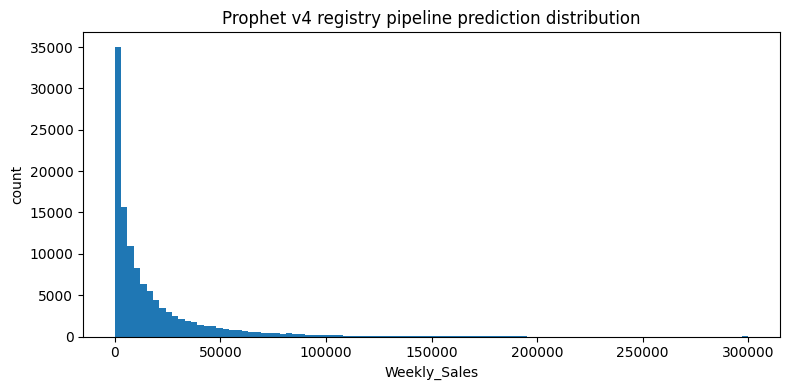

{'submission_path': '/content/drive/MyDrive/walmart_competition_inference/prophet/prophet_v4_submission_registry_raw_pipeline.csv', 'rows': 115064}


,Id,Weekly_Sales
0,1_1_2012-11-02,36219.280108
1,1_1_2012-11-09,22479.565662
2,1_1_2012-11-16,19443.283143
3,1_1_2012-11-23,19423.143794
4,1_1_2012-11-30,23137.936466


In [8]:
submission=test_raw[["Store","Dept","Date"]].copy(); submission["Weekly_Sales"]=predictions
submission.insert(0,"Id",submission.Store.astype(str)+"_"+submission.Dept.astype(str)+"_"+submission.Date.dt.strftime("%Y-%m-%d")); submission=submission[["Id","Weekly_Sales"]]
submission_path=OUTPUT_DIR/"prophet_v4_submission_registry_raw_pipeline.csv"; submission.to_csv(submission_path,index=False)
manifest={"registry_pipeline_uri":CONFIG["raw_pipeline_registry_uri"],"registry_pipeline_artifact":pipeline_artifact.name,"pipeline_type":type(pipeline).__name__,"pipeline_metadata":pipeline.metadata(),"test_rows":len(test_raw),"submission_rows":len(submission),"prediction_min":float(predictions.min()),"prediction_mean":float(predictions.mean()),"prediction_max":float(predictions.max()),"prediction_sha256":prediction_sha256}
manifest_path=OUTPUT_DIR/"prophet_v4_raw_pipeline_inference_manifest.json"; manifest_path.write_text(json.dumps(manifest,indent=2))
fig,ax=plt.subplots(figsize=(8,4)); ax.hist(predictions,bins=100); ax.set_title("Prophet v4 registry pipeline prediction distribution"); ax.set_xlabel("Weekly_Sales"); ax.set_ylabel("count"); plt.tight_layout(); hist_path=OUTPUT_DIR/"prophet_v4_prediction_histogram.png"; fig.savefig(hist_path,dpi=160); plt.show()
run.log({"inference/submission_rows":len(submission),"inference/prediction_min":manifest["prediction_min"],"inference/prediction_mean":manifest["prediction_mean"],"inference/prediction_max":manifest["prediction_max"],"inference/submission_preview":wandb.Table(dataframe=submission.head(2000)),"inference/prediction_histogram":wandb.Image(str(hist_path))})
artifact=wandb.Artifact(CONFIG["submission_artifact_name"],type="submission",metadata=manifest)
for file_path in [submission_path,manifest_path,hist_path]: artifact.add_file(str(file_path))
run.log_artifact(artifact,aliases=["registry-raw-pipeline","latest"]); run.summary.update(manifest)
print({"submission_path":str(submission_path),"rows":len(submission)}); display(submission.head())


## Optional Kaggle submission


In [16]:
import os
import json
from google.colab import userdata

kaggle_dir = os.path.expanduser('~/.kaggle')
os.makedirs(kaggle_dir, exist_ok=True)

try:
    KAGGLE_USERNAME = userdata.get('KAGGLE_USERNAME')
    KAGGLE_KEY = userdata.get('KAGGLE_API_TOKEN')

    kaggle_credentials = {
        "username": KAGGLE_USERNAME,
        "key": KAGGLE_KEY
    }

    with open(os.path.join(kaggle_dir, 'kaggle.json'), 'w') as f:
        json.dump(kaggle_credentials, f)

    os.chmod(os.path.join(kaggle_dir, 'kaggle.json'), 0o600)
    print("kaggle.json created successfully in ~/.kaggle/")
except Exception as e:
    print(f"Failed to create kaggle.json: {e}")
    print("Please ensure 'KAGGLE_USERNAME' and 'KAGGLE_API_TOKEN' secrets are configured correctly.")


kaggle.json created successfully in ~/.kaggle/


In [18]:
!kaggle competitions list --search "walmart-recruiting-store-sales-forecasting"

401 Client Error: Unauthorized for url: https://api.kaggle.com/v1/competitions.CompetitionApiService/ListCompetitions


In [20]:
# Print the username being used to verify it matches your Kaggle profile
import os
print(f"Attempting to authenticate as user: {os.environ.get('KAGGLE_USERNAME')}")

# Try to list files for this competition specifically to see if it's a rule-acceptance issue
!kaggle competitions files -c "walmart-recruiting-store-sales-forecasting"

Attempting to authenticate as user: konstantineendeladze
401 Client Error: Unauthorized for url: https://api.kaggle.com/v1/competitions.CompetitionApiService/ListDataFiles


After successfully running the above cell, please try re-running the Kaggle submission cell (`wO96AQYsIuHH`) once more.

In [22]:
if CONFIG["submit_to_kaggle"]:
    # Kaggle's current access-token flow uses a KAGGLE_API_TOKEN secret (usually starts with KGAT_).
    try:
        import os
        from google.colab import userdata
        kaggle_token = userdata.get("KAGGLE_API_TOKEN").strip()
    except Exception as exc:
        raise RuntimeError("Add KAGGLE_API_TOKEN to Colab Secrets and enable notebook access before submitting.") from exc
    if not kaggle_token:
        raise RuntimeError("KAGGLE_API_TOKEN is empty. Configure a fresh Kaggle access token in Colab Secrets.")
    os.environ["KAGGLE_API_TOKEN"] = kaggle_token
    kaggle_dir = Path("/root/.kaggle")
    kaggle_dir.mkdir(parents=True, exist_ok=True)
    access_token_path = kaggle_dir / "access_token"
    access_token_path.write_text(kaggle_token)
    access_token_path.chmod(0o600)

    cmd=["kaggle","competitions","submit","-c",CONFIG["kaggle_competition"],"-f",str(submission_path),"-m",CONFIG["kaggle_message"]]
    result=subprocess.run(cmd,capture_output=True,text=True,check=False); print(result.stdout); print(result.stderr)
    if result.returncode!=0:
        raise RuntimeError("Kaggle submission failed. If authentication now succeeds but you receive 403, accept the competition rules on Kaggle first.")
else: print("Kaggle upload skipped. Set CONFIG['submit_to_kaggle']=True to submit.")
run.finish()

Successfully submitted to Walmart Recruiting - Store Sales Forecasting

  0%|                                              | 0.00/3.82M [00:00<?, ?B/s]
100%|█████████████████████████████████████| 3.82M/3.82M [00:00<00:00, 12.7MB/s]

